# Lab 6 — Building a Brain Map from Scratch

In this lab you will run the complete statistical brain-mapping loop in miniature, on simulated data where *you* planted the true signal. You will simulate a two-condition experiment at many "voxels," build a single-subject map from trial-level data, combine subjects into a group-level map, threshold it with and without multiple comparisons correction, count true and false positives against the known ground truth, watch effect sizes inflate in selected voxels, and compare voxel-wise mapping against region-of-interest (ROI) tests.

Because every map here is built from data whose true signal is known exactly, you can see directly which claims a thresholded map does — and does not — license.

**How to run this notebook:** it runs in the browser (Pyodide), in Google Colab, or locally with any standard scientific Python installation (numpy, scipy, matplotlib). Run cells top to bottom. For the concepts behind each step, see the [chapter page](../ch06-inferences-about-mind-brain-and.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(6)
plt.rcParams["figure.dpi"] = 90

## 1. The generative model: plant the true signal

The brain mapping framework assumes that observed data are a mixture of **true signal** and **noise** (Figure 6.4 in the book). We cannot see the true signal in real data — but in a simulation we choose it. Our "brain" is a 40 × 40 grid of voxels (1,600 tests — a miniature of the ~330,000 in a real whole-brain analysis). The task effect is a raised response of 1 signal unit in two circular regions, and exactly zero everywhere else.

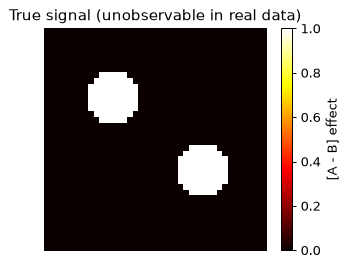

Voxels with true signal: 138 of 1600


In [2]:
nx = ny = 40                       # 40 x 40 voxel "slice"
xx, yy = np.meshgrid(np.arange(nx), np.arange(ny))

# True signal: [A - B] effect of 1 inside two circular regions, 0 elsewhere
truth = ((xx - 12)**2 + (yy - 12)**2 < 25) | ((xx - 28)**2 + (yy - 25)**2 < 25)
true_effect = 1.0 * truth

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(true_effect, cmap="hot", vmin=0)
ax.set_title("True signal (unobservable in real data)")
ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.8, label="[A - B] effect")
plt.show()

print(f"Voxels with true signal: {truth.sum()} of {truth.size}")

## 2. A single-subject map from trial-level data

One participant performs many trials of condition **A** (task) and condition **B** (control). At every voxel we record a response per trial: a baseline of 100 units, plus the true effect on A trials only, plus trial-to-trial noise. A two-sample t-test at each voxel — comparing the A trials against the B trials — gives the **single-subject map** (top panel of Figure 6.2 in the book).

Note what "massively univariate" means in practice: the *same simple test*, repeated independently at every voxel.

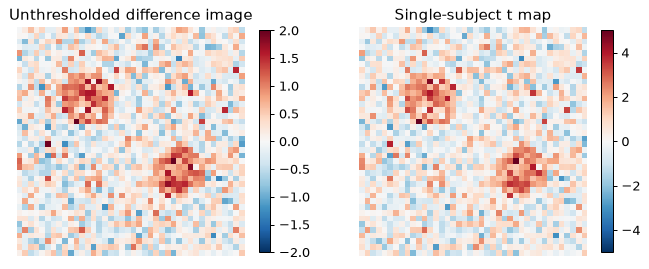

In [3]:
n_trials = 40                       # trials per condition
noise_sd = 2.0                      # trial-to-trial noise

# Trial-level responses at every voxel: baseline + effect (A only) + noise
trials_A = 100 + true_effect + noise_sd * rng.standard_normal((n_trials, ny, nx))
trials_B = 100 + noise_sd * rng.standard_normal((n_trials, ny, nx))

# Two-sample t-test at every voxel: is mean(A) different from mean(B)?
t_single, p_single = stats.ttest_ind(trials_A, trials_B, axis=0)

diff_image = trials_A.mean(axis=0) - trials_B.mean(axis=0)   # [A - B] difference image

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im0 = axes[0].imshow(diff_image, cmap="RdBu_r", vmin=-2, vmax=2)
axes[0].set_title("Unthresholded difference image")
im1 = axes[1].imshow(t_single, cmap="RdBu_r", vmin=-5, vmax=5)
axes[1].set_title("Single-subject t map")
for ax, im in zip(axes, [im0, im1]):
    ax.axis("off"); fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

The two true regions are visible, but so is plenty of structure that is pure noise. This is the central lesson of the unthresholded map: **noise produces convincing-looking blobs**. Hypothesis testing exists to tell us which blobs are unlikely to be chance.

## 3. A group-level map: population inference

A single-subject map cannot tell us how brains work *in general*. For that we need a group of participants and a test of whether the effect generalizes — treating participants as a random effect (bottom panel of Figure 6.2).

The standard recipe:

1. Compute one **[A − B] difference image per participant** (as in step 2).
2. At every voxel, run a **one-sample t-test across participants** against zero.

Here we simulate each participant's difference image directly: the shared true effect, plus between-person noise (people genuinely vary in effect magnitude, and each person's estimate carries measurement error).

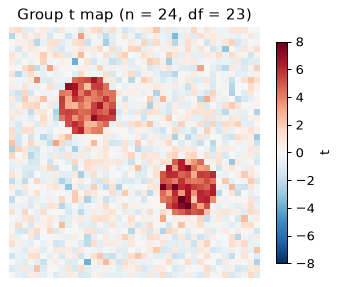

In [4]:
n_sub = 24                          # participants
subj_sd = 1.0                       # between-person variability + estimation noise

# One [A - B] difference image per participant = true effect + noise
diff_imgs = true_effect + subj_sd * rng.standard_normal((n_sub, ny, nx))

# One-sample t-test across participants, separately at every voxel
t_map, p_map = stats.ttest_1samp(diff_imgs, 0, axis=0)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(t_map, cmap="RdBu_r", vmin=-8, vmax=8)
ax.set_title(f"Group t map (n = {n_sub}, df = {n_sub - 1})")
ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.8, label="t")
plt.show()

## 4. Threshold the map: multiple comparisons

Each voxel's P value answers: *if the true effect here were zero, how often would a t this extreme occur by chance?* With 1,600 tests, a lenient threshold guarantees false positives — at $\alpha = 0.05$ uncorrected we *expect* about $0.05 \times 1462 \approx 73$ false-positive voxels from the null voxels alone.

We compare three standard choices:

- **Uncorrected** $P < 0.05$ — controls the error rate per voxel, not per map.
- **Bonferroni** $P < 0.05 / 1600$ — controls the family-wise error rate (FWER): the chance of *any* false positive in the whole map.
- **False discovery rate (FDR)**, Benjamini–Hochberg — controls the expected *proportion* of significant voxels that are false positives; a middle ground.

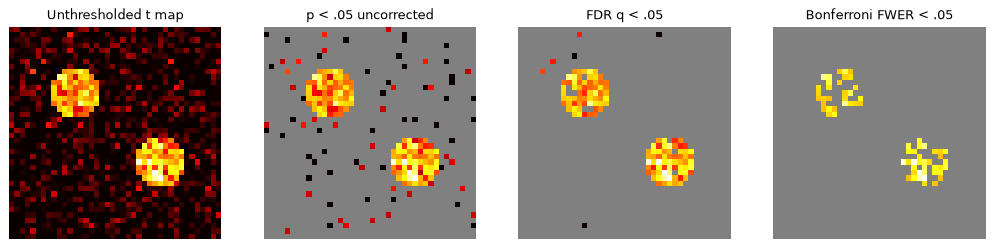

In [5]:
def bh_fdr_mask(p, q=0.05):
    """Benjamini-Hochberg FDR: return boolean mask of significant tests."""
    pf = p.ravel()
    order = np.argsort(pf)
    m = pf.size
    below = pf[order] <= q * np.arange(1, m + 1) / m
    mask = np.zeros(m, dtype=bool)
    if below.any():
        k = np.max(np.nonzero(below))          # largest rank passing the BH line
        mask[order[:k + 1]] = True
    return mask.reshape(p.shape)

alpha = 0.05
n_vox = nx * ny
sig_unc  = p_map < alpha                       # no correction
sig_bonf = p_map < alpha / n_vox               # Bonferroni (FWER)
sig_fdr  = bh_fdr_mask(p_map, q=alpha)         # Benjamini-Hochberg (FDR)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
panels = [(t_map, "Unthresholded t map"),
          (np.where(sig_unc,  t_map, np.nan), "p < .05 uncorrected"),
          (np.where(sig_fdr,  t_map, np.nan), "FDR q < .05"),
          (np.where(sig_bonf, t_map, np.nan), "Bonferroni FWER < .05")]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(np.zeros_like(t_map), cmap="gray", vmin=-1, vmax=1)   # dark underlay
    ax.imshow(img, cmap="hot", vmin=0, vmax=8)
    ax.set_title(title, fontsize=10); ax.axis("off")
plt.show()

Because we know the truth, we can score each map — something never possible with real data. **True positives** are significant voxels inside the true regions; **false positives** are significant voxels outside them.

In [6]:
def score(mask, name):
    tp = (mask & truth).sum()               # significant AND truly active
    fp = (mask & ~truth).sum()              # significant but truly null
    sens = tp / truth.sum()                 # proportion of true voxels detected
    print(f"{name:<22} significant: {mask.sum():>4}   "
          f"true pos: {tp:>3}   false pos: {fp:>3}   sensitivity: {sens:.2f}")

print(f"Ground truth: {truth.sum()} active voxels, {(~truth).sum()} null voxels\n")
score(sig_unc,  "Uncorrected p < .05")
score(sig_fdr,  "FDR q < .05")
score(sig_bonf, "Bonferroni")

Ground truth: 138 active voxels, 1462 null voxels

Uncorrected p < .05    significant:  213   true pos: 138   false pos:  75   sensitivity: 1.00
FDR q < .05            significant:  135   true pos: 129   false pos:   6   sensitivity: 0.93
Bonferroni             significant:   65   true pos:  65   false pos:   0   sensitivity: 0.47


The tradeoff of Figure 6.4 in numbers: the uncorrected map detects nearly all true voxels but is contaminated by dozens of false positives scattered across the "brain." Bonferroni all but eliminates false positives, at the cost of missing real signal near the edges of the true regions. FDR sits in between. **No threshold reveals the truth exactly** — a thresholded map is a decision procedure with tunable error rates, not a photograph of the true signal.

## 5. Significant voxels overestimate their own effects

The chapter makes a subtle but crucial point: voxels survive thresholding partly because noise *happened to favor* the hypothesis there. So if you estimate effect sizes from the voxels you selected, the estimates are biased upward — the "winner's curse." Let's verify, using the truly-active voxels (true effect = 1.0 everywhere among them).

True effect size (planted):                      1.00
Mean estimate, ALL truly active voxels:          0.99
Mean estimate, SELECTED (significant) voxels:    1.12
Mean |estimate|, false-positive voxels (unc.):   0.45  (true effect there: 0.00)


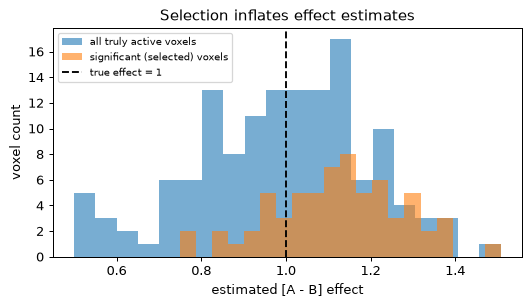

In [7]:
est_effect = diff_imgs.mean(axis=0)             # estimated effect per voxel

in_truth          = est_effect[truth]                   # all truly active voxels
in_truth_selected = est_effect[truth & sig_bonf]        # ...that also passed Bonferroni

print(f"True effect size (planted):                      1.00")
print(f"Mean estimate, ALL truly active voxels:          {in_truth.mean():.2f}")
print(f"Mean estimate, SELECTED (significant) voxels:    {in_truth_selected.mean():.2f}")
print(f"Mean |estimate|, false-positive voxels (unc.):   "
      f"{np.abs(est_effect[~truth & sig_unc]).mean():.2f}  (true effect there: 0.00)")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(in_truth, bins=20, alpha=0.6, label="all truly active voxels")
ax.hist(in_truth_selected, bins=20, alpha=0.6, label="significant (selected) voxels")
ax.axvline(1.0, color="k", ls="--", label="true effect = 1")
ax.set_xlabel("estimated [A - B] effect"); ax.set_ylabel("voxel count")
ax.legend(fontsize=8); ax.set_title("Selection inflates effect estimates")
plt.tight_layout(); plt.show()

Averaged over *all* truly active voxels, the estimate is unbiased. Averaged over only the voxels that *survived thresholding*, it is too large — and false-positive voxels show apparent "effects" of sizable magnitude where the truth is exactly zero. This is why a map identifies *where* non-zero effects likely exist but does not provide valid estimates of *how large* they are.

## 6. The other end of the continuum: an a priori ROI

Instead of testing 1,600 voxels, suppose we had precise prior knowledge and averaged the signal within a single predefined region — one test, no correction needed (Figure 6.5 in the book). This maximizes power and avoids selection bias... **if the hypothesis is right**. We test two ROIs: one placed exactly on a true region, and one displaced onto mostly-null territory nearby.

Correct a priori ROI  mean effect =  0.97   t(23) = 44.73   p = 7.2e-24
Misplaced ROI        mean effect =  0.02   t(23) =  0.90   p = 0.38


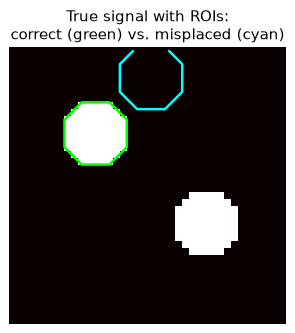

In [8]:
roi_correct   = (xx - 12)**2 + (yy - 12)**2 < 25       # exactly on true region 1
roi_misplaced = (xx - 20)**2 + (yy - 4)**2  < 25       # nearby, but wrong

for roi, name in [(roi_correct, "Correct a priori ROI"),
                  (roi_misplaced, "Misplaced ROI      ")]:
    roi_avg = diff_imgs[:, roi].mean(axis=1)           # one value per subject
    t_roi, p_roi = stats.ttest_1samp(roi_avg, 0)
    print(f"{name}  mean effect = {roi_avg.mean():>5.2f}   "
          f"t({n_sub - 1}) = {t_roi:>5.2f}   p = {p_roi:.2g}")

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(true_effect, cmap="hot", vmin=0)
ax.contour(roi_correct, colors="lime", linewidths=2)
ax.contour(roi_misplaced, colors="cyan", linewidths=2)
ax.set_title("True signal with ROIs:\ncorrect (green) vs. misplaced (cyan)")
ax.axis("off")
plt.show()

The correct ROI yields a single decisive, unbiased test — stronger than any single-voxel result under Bonferroni. The misplaced ROI, sampling mostly null voxels, misses the effect entirely. This is the continuum of Figure 6.5: prior spatial precision buys power and unbiased estimates, but a wrong prior can make a real effect invisible. And the advantage is legitimate only if the ROI was truly chosen *before* seeing the data — moving it afterward and reporting the best result is P-hacking.

## Wrap-up

You have run the entire brain-mapping loop on data with known ground truth:

- **Maps are statistical constructions** — hypothesis tests repeated at every voxel, not pictures of activity.
- **Group maps** test whether effects generalize across people; single-subject maps do not.
- **Thresholds trade error types**: uncorrected maps are littered with false positives; stringent correction sacrifices sensitivity; FDR is a middle ground.
- **Selected voxels overestimate their effects**, so significance tells you *where*, not *how much*.
- **A priori ROIs** maximize power and avoid bias — but only when prior knowledge is accurate and honestly a priori.

**Try it yourself:** shrink the true effect to 0.5, raise `n_sub` to 50, or change the noise SD — and watch how the three thresholded maps and the ROI tests respond. Then return to the [chapter page](../ch06-inferences-about-mind-brain-and.md) for the assumptions that all of this rests on.